##### Author: Jimin Kim (jk55@uw.edu)
##### Version 1.5.0

# Lab 3 Report

## Group Members: Sam Decker, Dadhich Sparsh
## Group Name for Leaderboard: crashed out coders


In [137]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

from PIL import Image
%matplotlib inline

In [138]:
from IPython.display import Image as ipyimage #For displaying images in colab jupyter cell

### Exercise 1: Generalized function for subsetting pixels

In [140]:
e1_img = Image.open('sample_image_1.jpg').convert('L')
e1_img = np.array(e1_img)     # 8-bit code grayscale

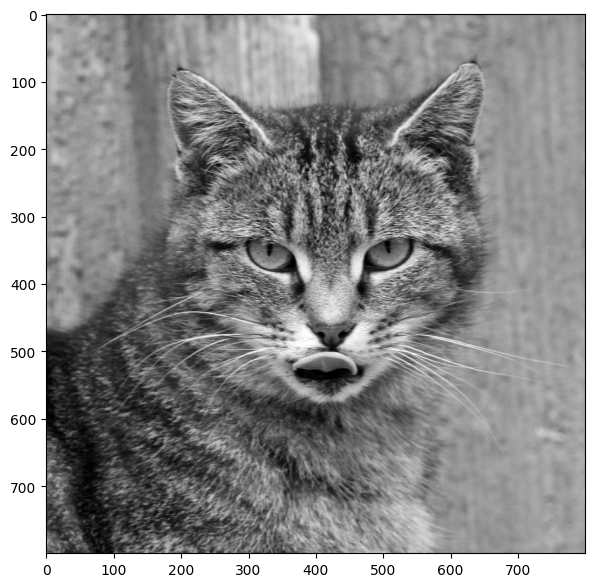

In [141]:
fig = plt.figure(figsize=(7, 7))

plt.imshow(e1_img, cmap = 'gray')

In [142]:
def subset_pixels(image, min_pixel_depth, max_pixel_depth, replacement_val):

    # YOUR CODE HERE
    # Make sure you create a copy of the image via new_image = image.copy() to avoid tempering the global variable
    output_image = image.copy()
    output_image[output_image < min_pixel_depth] = replacement_val ## truncate any color values below or above threshold to the given replacement value
    output_image[output_image > max_pixel_depth] = replacement_val
    return output_image

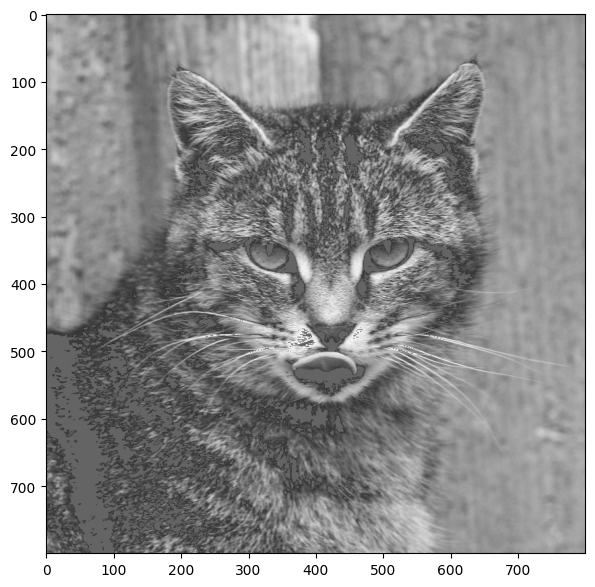

In [143]:
# min_pixel_depth = 50, max_pixel_depth = 250, replacement_val = 100

fig = plt.figure(figsize=(7, 7))

e1_output1 = subset_pixels(image = e1_img, min_pixel_depth = 50, max_pixel_depth = 250, replacement_val = 100)

plt.imshow(e1_output1, cmap = 'gray', vmin = 0, vmax = 255)

plt.savefig('e1_output1.png')

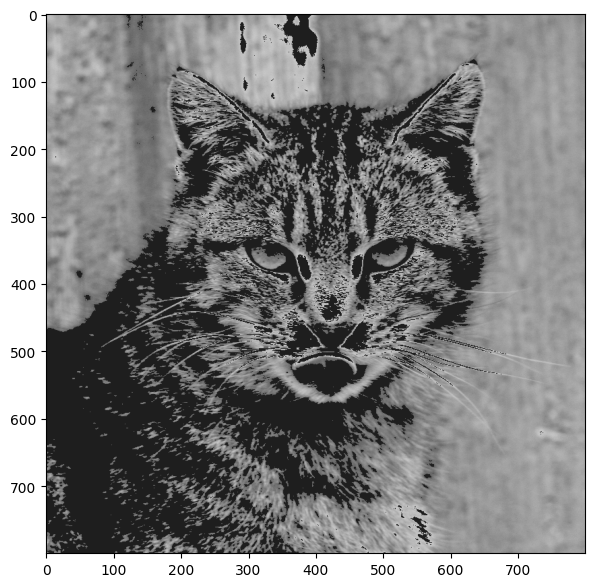

In [144]:
# min_pixel_depth = 100, max_pixel_depth = 200, replacement_val = 30

fig = plt.figure(figsize=(7, 7))

e1_output2 = subset_pixels(image = e1_img, min_pixel_depth = 100, max_pixel_depth = 200, replacement_val = 30)

plt.imshow(e1_output2, cmap = 'gray', vmin = 0, vmax = 255)

plt.savefig('e1_output2.png')

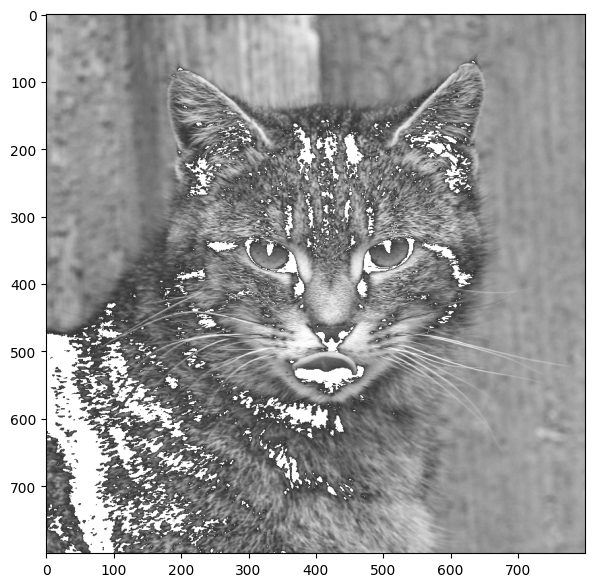

In [145]:
# min_pixel_depth = 50, max_pixel_depth = 255, replacement_val = 255

fig = plt.figure(figsize=(7, 7))

e1_output3 = subset_pixels(image = e1_img, min_pixel_depth = 50, max_pixel_depth = 255, replacement_val = 255)

plt.imshow(e1_output3, cmap = 'gray', vmin = 0, vmax = 255)

plt.savefig('e1_output3.png')

### Exercise 2: Thumbnail generator function

In [147]:
e2_img = mpimg.imread('sample_image_2.jpg')
e2_img = np.array(e2_img)

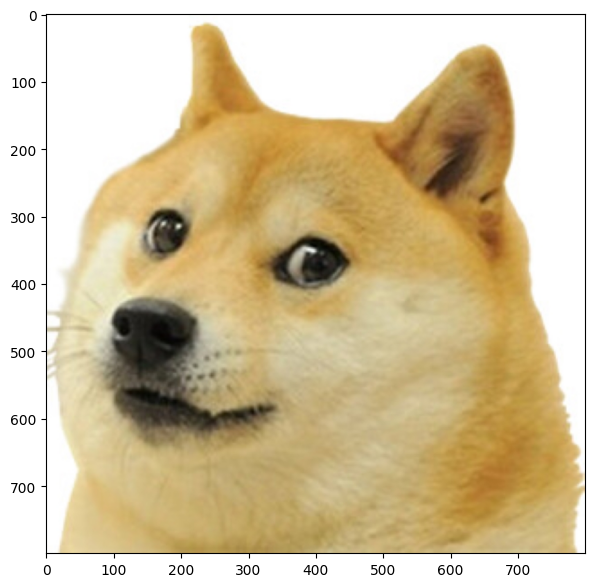

In [148]:
fig = plt.figure(figsize=(7, 7))

plt.imshow(e2_img)

In [149]:
def create_thumbnail(image, downsampling_rate):

    # YOUR CODE HERE
    # USE SEGMENT AVERAGE METHOD (Lecture slide 23) NOT PICK ONE METHOD
    # MAKE SURE YOU ROUND YOUR AVERAGED PIXELS TO INTEGER TO CONFORM TO RGB 8-BIT CODING

    # calculate the dimensions of the new downscaled image
    original_size = image.shape[0]
    new_size = original_size // downsampling_rate
    # create a new empty array to place the averaged values in
    output_image = np.zeros((new_size, new_size, 3), dtype= "uint8")

    for i in range(0, new_size):
      for j in range(0, new_size):

        ## below will be the boundaries for the segment of this interation
        initial_row = i*downsampling_rate
        end_row = initial_row + downsampling_rate # step by downsampling_rate
        initial_column = j*downsampling_rate
        end_column = initial_column + downsampling_rate

        ## and here is the subarray instantiated using the bounds we found
        partition = image[initial_row:end_row, initial_column:end_column]

        ## compute average color value for each channel
        averaged = np.mean(partition, axis=(0, 1))

        # truncate the values into type int 0,255 inclusive
        output_image[i, j] = averaged.astype("uint8")

    return output_image

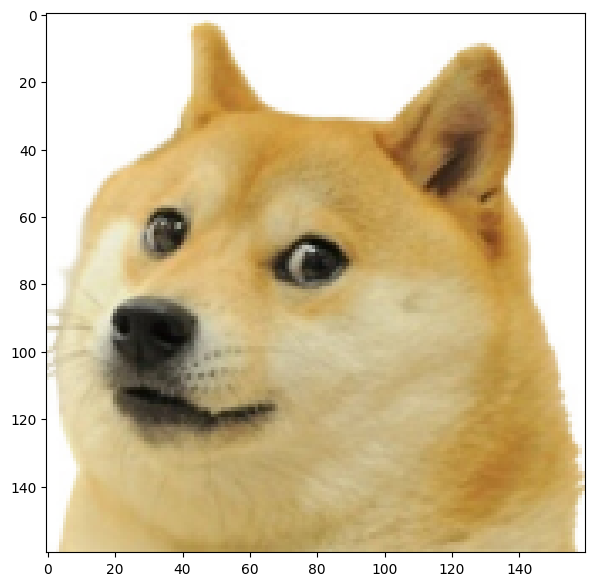

In [150]:
# downsampling rate x5

fig = plt.figure(figsize=(7, 7))

e2_output1 = create_thumbnail(image = e2_img, downsampling_rate = 5)

plt.imshow(e2_output1, vmin = 0, vmax = 255)

plt.savefig('e2_output1.png')

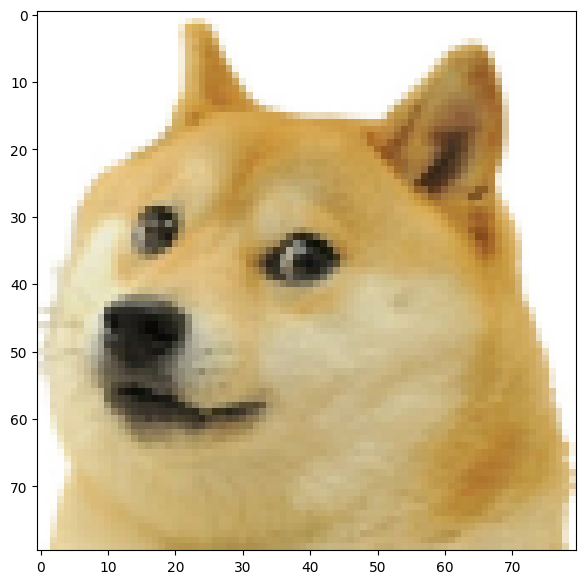

In [151]:
# downsampling rate x10

fig = plt.figure(figsize=(7, 7))

e2_output2 = create_thumbnail(image = e2_img, downsampling_rate = 10)

plt.imshow(e2_output2, vmin = 0, vmax = 255)

plt.savefig('e2_output2.png')

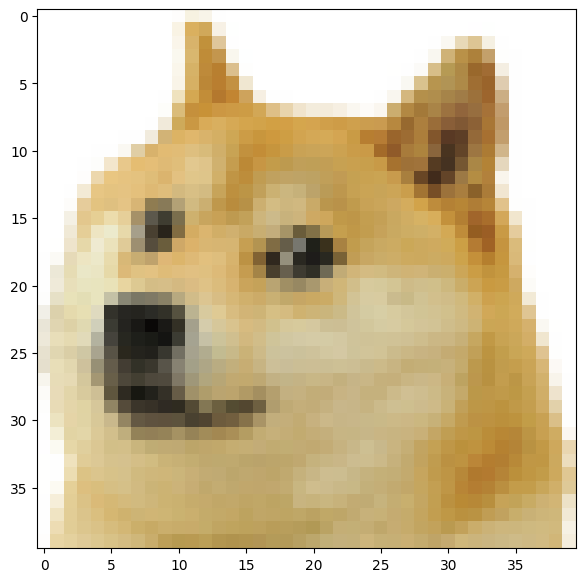

In [152]:
# downsampling rate x20

fig = plt.figure(figsize=(7, 7))

e2_output3 = create_thumbnail(image = e2_img, downsampling_rate = 20)

plt.imshow(e2_output3, vmin = 0, vmax = 255)

plt.savefig('e2_output3.png')

## Extra credit: Code efficiency
### Achieve a runtime speed of < 100ms

In [153]:
timeit -n 1 -r 7 e2_output2 = create_thumbnail(image = e2_img, downsampling_rate = 5)

454 ms ± 33.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Exercise 3: Generalized image blender function

In [155]:
e3_img1 = mpimg.imread('sample_image_1.jpg')
e3_img2 = mpimg.imread('sample_image_2.jpg')
e3_img3 = mpimg.imread('sample_image_3.jpg')
e3_img4 = mpimg.imread('sample_image_4.jpg')
e3_img5 = mpimg.imread('sample_image_5.jpg')

e3_img1 = np.array(e3_img1)
e3_img2 = np.array(e3_img2)
e3_img3 = np.array(e3_img3)
e3_img4 = np.array(e3_img4)
e3_img5 = np.array(e3_img5)

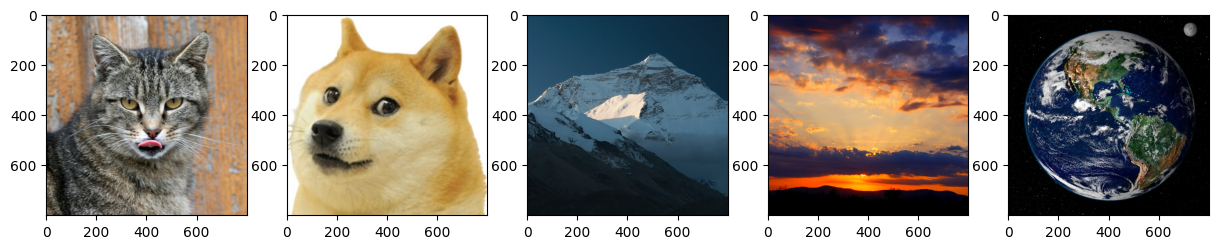

In [156]:
fig = plt.figure(figsize=(15, 15))

plt.subplot(1,5,1)
plt.imshow(e3_img1, vmin = 0, vmax = 255)

plt.subplot(1,5,2)
plt.imshow(e3_img2, vmin = 0, vmax = 255)

plt.subplot(1,5,3)
plt.imshow(e3_img3, vmin = 0, vmax = 255)

plt.subplot(1,5,4)
plt.imshow(e3_img4, vmin = 0, vmax = 255)

plt.subplot(1,5,5)
plt.imshow(e3_img5, vmin = 0, vmax = 255)

In [157]:
def blend_images(image_list, weight_list): # averages given pictures by weight

    width = (image_list[0]).shape[0] # obtain dimensions of images
    length = (image_list[0]).shape[1]

    output_image = np.zeros((width, length, 3), dtype= "float64") # blank canvas with parameters width, length, and 3 for rgb color channel

    for image, weight in zip(image_list, weight_list): # weigh each image before adding it to the output file
      image = image.astype(np.float64)
      output_image += image*weight # sum each image to output_image elementwise

    output_image /= np.max(output_image) # normalize data to valid range
                                         # 0-255, and 0-1 for color channels
                                         # likely needed because of floating
                                         # point precision errors
    return output_image

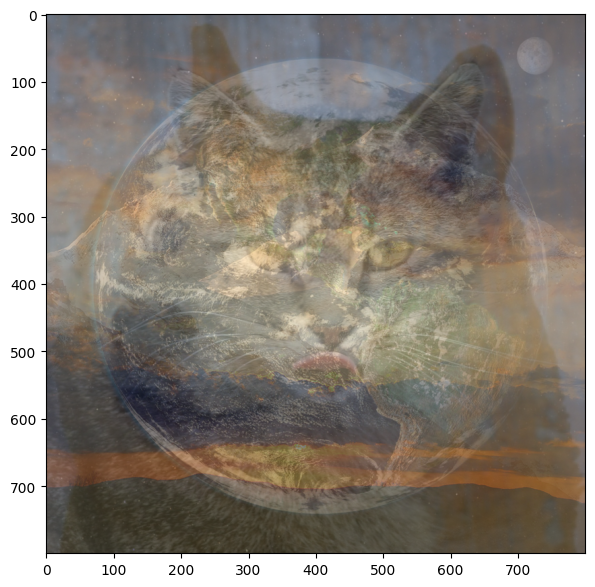

In [158]:
# Blend all 5 images with equal weights

e3_part1_image_list =[e3_img1, e3_img2, e3_img3, e3_img4, e3_img5]
e3_part1_weight_list = [0.2, 0.2, 0.2, 0.2, 0.2]

e3_output1 = blend_images(image_list = e3_part1_image_list, weight_list = e3_part1_weight_list)

fig = plt.figure(figsize=(7, 7))

plt.imshow(e3_output1, vmin = 0, vmax = 255)

plt.savefig('e3_output1.png')

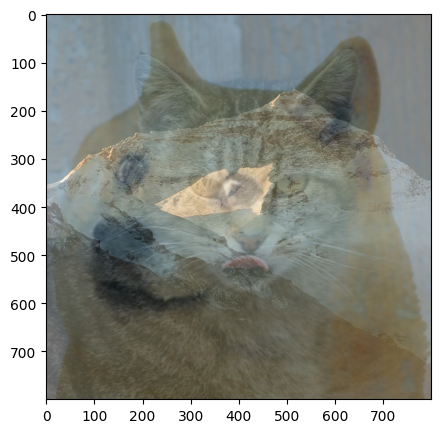

In [159]:
# Blend first 3 images with different weights

e3_part2_image_list =[e3_img1, e3_img2, e3_img3]
e3_part2_weight_list = [0.2, 0.3, 0.5]

e3_output2 = blend_images(image_list = e3_part2_image_list, weight_list = e3_part2_weight_list)

fig = plt.figure(figsize=(5, 5))

plt.imshow(e3_output2, vmin = 0, vmax = 255)

plt.savefig('e3_output2.png')

### Exercise 4: Image rotation function

In [161]:
e4_img = mpimg.imread('sample_image_2.jpg')
e4_img = np.array(e4_img)

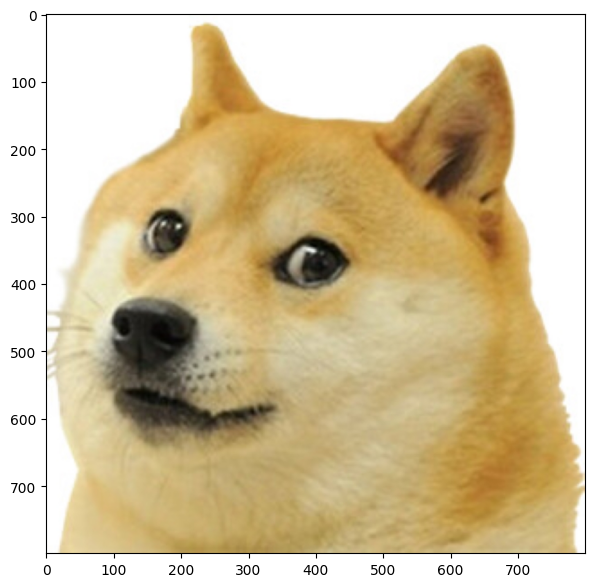

In [162]:
fig = plt.figure(figsize=(7, 7))

plt.imshow(e4_img, vmin = 0, vmax = 255)

In [163]:
def rotate_image(image, rotate_angle): # rotate angle takes one of 0, 90, 180, 270

    # YOUR CODE HERE
    # Make sure you create a copy of the image via new_image = image.copy() to avoid tempering the global variable
    output_image = image.copy()
    def switch_case(rotate_angle, image):

      if rotate_angle == 0:
        return image

      elif rotate_angle == 90: # [[0, 1][2, 3]] -> [[2, 3][0, 1]]
                               # [[2, 0][3, 1]]
        return np.transpose(np.flipud(output_image), axes=(1, 0, 2))

      elif rotate_angle == 180:
        return np.flipud(output_image)

      elif rotate_angle == 270: # [[0, 1][2, 3]] -> [[0, 2][1, 3]]
        return np.transpose(output_image, axes=(1, 0, 2))

      else:
        print("the provided angle is not supported")
        return None

    rotated_image = switch_case(rotate_angle, output_image)
    return rotated_image



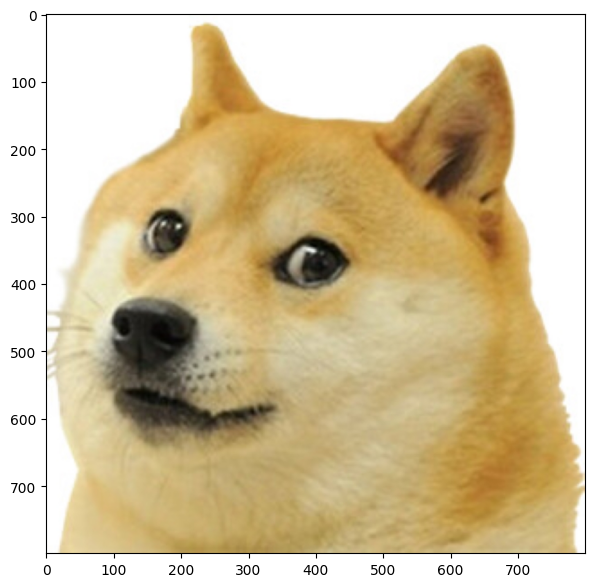

In [164]:
# Rotate the image by 0 degrees - This should result in identity

e4_output1 = rotate_image(image = e4_img, rotate_angle = 0)

fig = plt.figure(figsize=(7, 7))

plt.imshow(e4_output1, vmin = 0, vmax = 255)

plt.savefig('e4_output1.png')

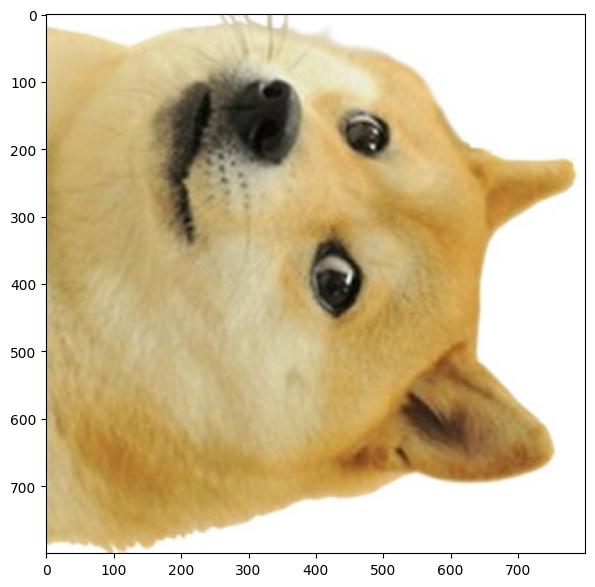

In [165]:
# Rotate the image by 90 degrees

e4_output2 = rotate_image(image = e4_img, rotate_angle = 90)

fig = plt.figure(figsize=(7, 7))

plt.imshow(e4_output2, vmin = 0, vmax = 255)

plt.savefig('e4_output2.png')

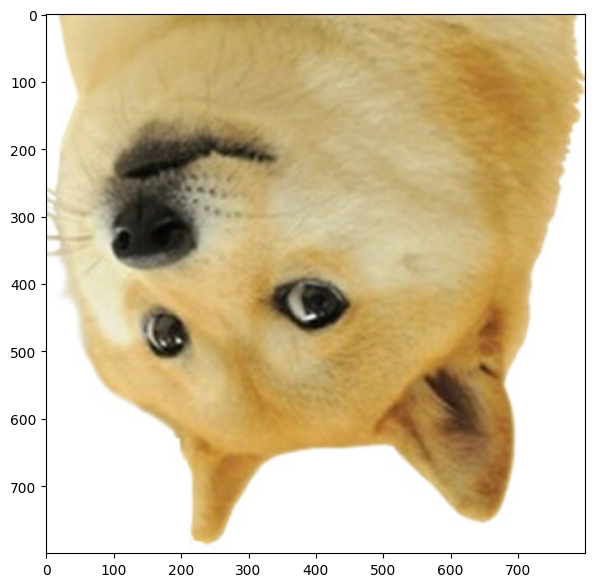

In [166]:
# Rotate the image by 180 degrees

e4_output3 = rotate_image(image = e4_img, rotate_angle = 180)

fig = plt.figure(figsize=(7, 7))

plt.imshow(e4_output3, vmin = 0, vmax = 255)

plt.savefig('e4_output3.png')

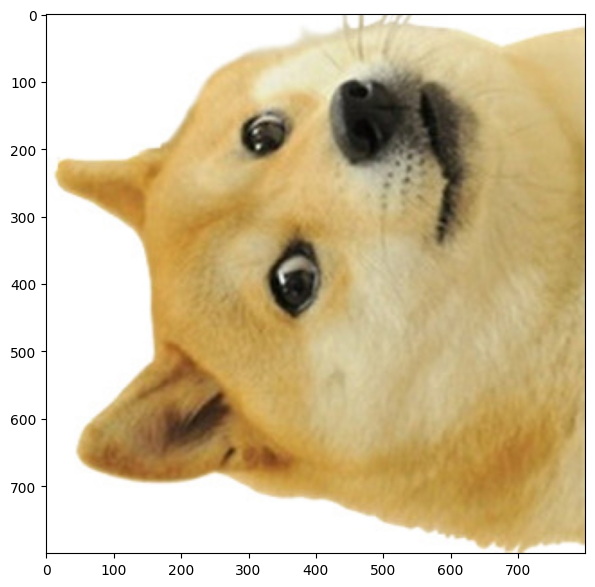

In [167]:
# Rotate the image by 270 degrees

e4_output4 = rotate_image(image = e4_img, rotate_angle = 270)

fig = plt.figure(figsize=(7, 7))

plt.imshow(e4_output4, vmin = 0, vmax = 255)

plt.savefig('e4_output4.png')

## Extra credit: Code efficiency
### Achieve a runtime speed of < 5ms

In [168]:
timeit -n 1 -r 7 e4_output2 = rotate_image(image = e4_img, rotate_angle = 90)

297 µs ± 140 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Exercise 5: 2D Gaussian image generator

In [170]:
x_range = np.arange(-25, 25, 1)
y_range = np.arange(-25, 25, 1)[::-1]

X, Y = np.meshgrid(x_range, y_range) # More detail on documentation
                                     # https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html

In [171]:
print(X, X.shape) # Set of x-coordinates in the function domain

[[-25 -24 -23 ...  22  23  24]
 [-25 -24 -23 ...  22  23  24]
 [-25 -24 -23 ...  22  23  24]
 ...
 [-25 -24 -23 ...  22  23  24]
 [-25 -24 -23 ...  22  23  24]
 [-25 -24 -23 ...  22  23  24]] (50, 50)


In [172]:
print(Y, Y.shape) # Set of y-coordinates in the function domain

[[ 24  24  24 ...  24  24  24]
 [ 23  23  23 ...  23  23  23]
 [ 22  22  22 ...  22  22  22]
 ...
 [-23 -23 -23 ... -23 -23 -23]
 [-24 -24 -24 ... -24 -24 -24]
 [-25 -25 -25 ... -25 -25 -25]] (50, 50)


In [173]:
def vis_2d_gaussian(X, Y, sigma_x, sigma_y, x0, y0, A, cmap):

    # parsed the function into smaller pieces for readability
    x_delta_squared = (X - x0)**2
    y_delta_squared = (Y - y0)**2
    sigma_x_squared = 2 * sigma_x**2
    sigma_y_squared = 2 * sigma_y**2
    distribution = A*np.exp(-1 * ((x_delta_squared / sigma_x_squared) + (y_delta_squared / sigma_y_squared)))

    plt.imshow(distribution, cmap=cmap)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('2D Gaussian Contour')
    plt.show()

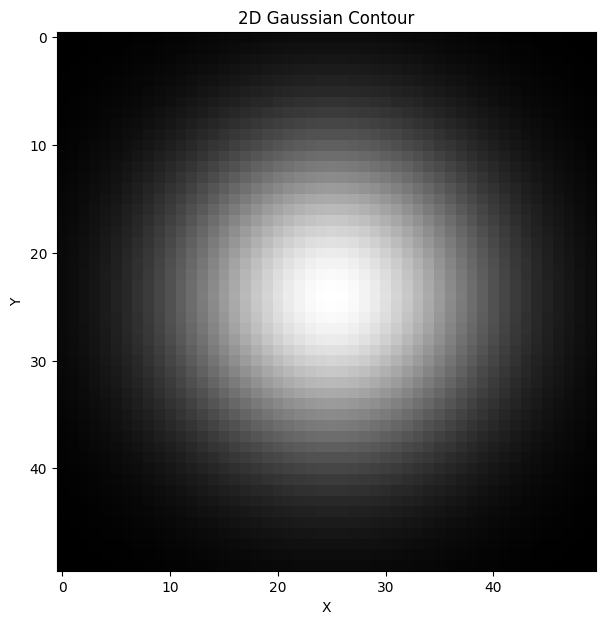

<Figure size 640x480 with 0 Axes>

In [174]:
# First parameter set: sigma_x = 10, sigma_y = 10, x0 = 0, y0 = 0
# cmap = 'gray'

fig = plt.figure(figsize=(7, 7))

vis_2d_gaussian(X, Y, sigma_x = 10, sigma_y = 10, x0 = 0, y0 = 0, A = 255, cmap = 'gray')

plt.savefig('e5_output1.png')

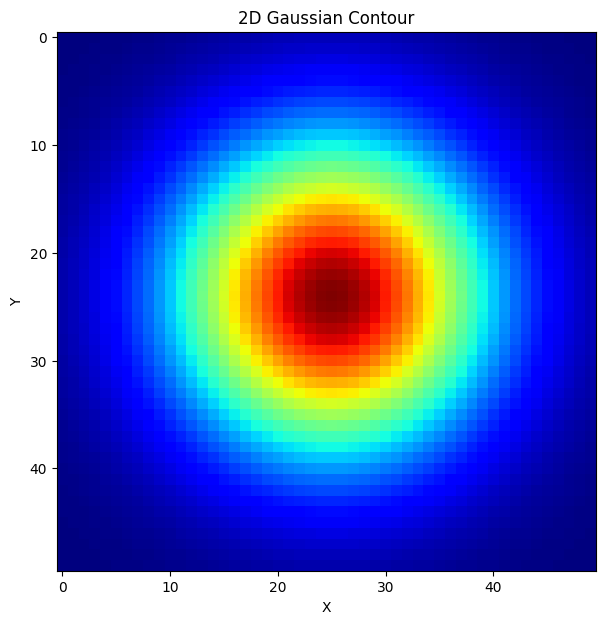

<Figure size 640x480 with 0 Axes>

In [175]:
# First parameter set
# cmap = 'jet'

fig = plt.figure(figsize=(7, 7))

vis_2d_gaussian(X, Y, sigma_x = 10, sigma_y = 10, x0 = 0, y0 = 0, A = 255, cmap = 'jet')

plt.savefig('e5_output2.png')

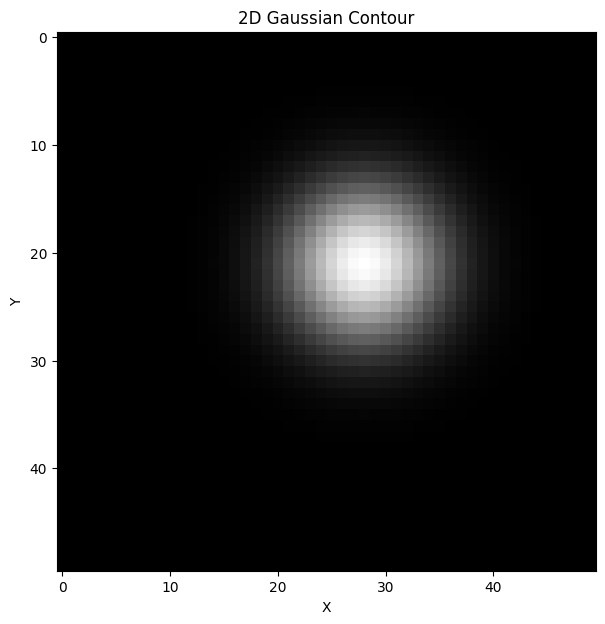

<Figure size 640x480 with 0 Axes>

In [176]:
# Second parameter set: sigma_x = 5, sigma_y = 5, x0 = 3, y = 3
# grayscale color specturm

fig = plt.figure(figsize=(7, 7))

vis_2d_gaussian(X, Y, sigma_x = 5, sigma_y = 5, x0 = 3, y0 = 3, A = 255, cmap = 'gray')

plt.savefig('e5_output1.png')

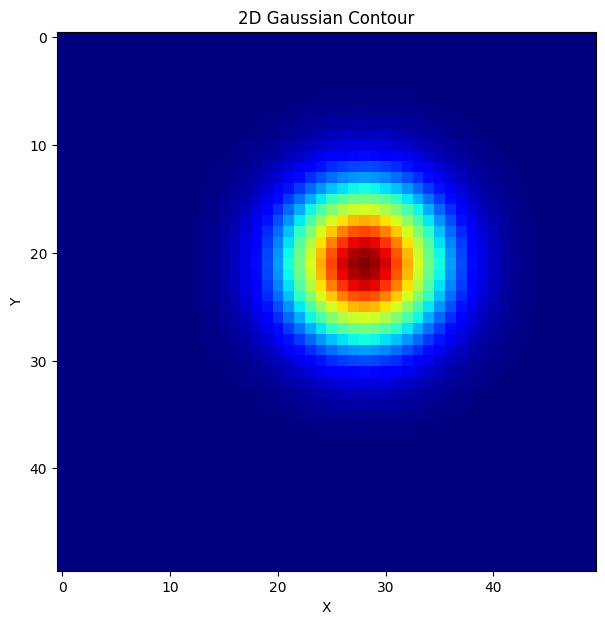

<Figure size 640x480 with 0 Axes>

In [177]:
# Second parameter set: sigma_x = 5, sigma_y = 5, x0 = 3, y = 3
# jet color specturm

fig = plt.figure(figsize=(7, 7))

vis_2d_gaussian(X, Y, sigma_x = 5, sigma_y = 5, x0 = 3, y0 = 3, A = 255, cmap = 'jet')

plt.savefig('e5_output2.png')